# 1. CRAP ALGORITHM IMPLEMENTATION

In [1]:
import numpy as np
from math import *
from matplotlib import pyplot as plt

def ToCartesian(angles, l1=30, l2=33):
    """
    Converts joint angles to Cartesian coordinates.

    Parameters:
        angles (list or array): Joint angles [theta1, theta2] in radians.
        l1 (float): Length of the first link.
        l2 (float): Length of the second link.

    Returns:
        (x, y): Cartesian coordinates of the end effector.
    """
    theta1, theta2 = angles
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y

I1 = 0.025
I2 = 0.045
m1 = 1.4
m2 = 1
l1 = 0.3
l2 = 0.33
s1 = 0.11
s2 = 0.16
K = 1 / 0.06
tau = 0.06


a1 = I1 + I2 + m2 * l1 * l1
a2 = m2 * l1 * s2
a3 = I2

Viscous = np.array([[0.05, 0.025], [0.025, 0.05]])

def Linearization(x,dt, N = 8):
    TimeConstant = 1 / 0.06  # Torque dynamics coefficient

    # Extract state variables according to the given order
    theta1, theta2, dtheta1, dtheta2, tau1, tau2 = x[:6]

    # Coriolis force
    C = np.array([
        -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.sin(theta2),
        dtheta1**2 * a2 * np.sin(theta2)
    ])
    
    # Partial derivatives of C
    dCdte = np.array([
        -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.cos(theta2),
        dtheta1**2 * a2 * np.cos(theta2)
    ])
    dCdos = np.array([
        -dtheta2 * 2 * a2 * np.sin(theta2),
        2 * dtheta1 * a2 * np.sin(theta2)
    ])
    dCdoe = np.array([
        (-2 * dtheta1 - 2 * dtheta2) * a2 * np.sin(theta2),
        0
    ])
    
    # Inertia matrix
    M = np.array([
        [a1 + 2 * a2 * np.cos(theta2), a3 + a2 * np.cos(theta2)],
        [a3 + a2 * np.cos(theta2), a3]
    ])
    
    Minv = np.linalg.inv(M)
    
    # Derivative of inertia matrix
    dM = np.array([
        [-2 * a2 * np.sin(theta2), -a2 * np.sin(theta2)],
        [-a2 * np.sin(theta2), 0]
    ])
    
    # Compute acceleration dependencies
    dtheta = np.array([dtheta1, dtheta2])
    tau = np.array([tau1, tau2])

    d_accel_dtheta1 = -Minv @ (dCdos + Viscous @ np.array([1, 0]))
    d_accel_tau = Minv @ np.array([1, 0])
    d_accel_theta2 = -Minv @ (dM @ Minv @ (tau - C - Viscous @ dtheta)) - Minv @ dCdte
    d_accel_dtheta2 = -Minv @ (dCdoe + Viscous @ np.array([0, 1]))
    d_accel_tau2 = Minv @ np.array([0, 1])

    # Construct the Jacobian matrix
    A = np.zeros((N,N))

    # Assign known structure
    A[0, 2] = 1  # d(theta1)/d(dtheta1)
    A[1, 3] = 1  # d(theta2)/d(dtheta2)

    # Acceleration contributions
    A[2, 2] = d_accel_dtheta1[0]  # d(dtheta1)/d(dtheta1)
    A[2, 1] = d_accel_theta2[0]
    A[2, 3] = d_accel_dtheta2[0]  # d(dtheta1)/d(dtheta2)
    A[2, 4] = d_accel_tau[0]  # d(dtheta1)/d(tau1)
    A[2, 5] = d_accel_tau2[0]  # d(dtheta1)/d(tau2)

    A[3, 2] = d_accel_dtheta1[1]  # d(dtheta2)/d(dtheta1)
    A[3, 1] = d_accel_theta2[1]
    A[3, 3] = d_accel_dtheta2[1]  # d(dtheta2)/d(dtheta2)
    A[3, 4] = d_accel_tau[1]  # d(dtheta2)/d(tau1)
    A[3, 5] = d_accel_tau2[1]  # d(dtheta2)/d(tau2)

    # Torque dynamics
    A[4, 4] = -TimeConstant
    A[5, 5] = -TimeConstant

    
    return A

def Loaded_Dynamics(x,load_param,dt, N = 8):
    TimeConstant = 1 / 0.06  # Torque dynamics coefficient
    load_s,load_e = load_param

    # Extract state variables according to the given order
    theta1, theta2, dtheta1, dtheta2, tau1, tau2 = x[:6]

    # Coriolis force
    C = np.array([
        -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.sin(theta2),
        dtheta1**2 * a2 * np.sin(theta2)
    ])
    
    # Partial derivatives of C
    dCdte = np.array([
        -dtheta2 * (2 * dtheta1 + dtheta2) * a2 * np.cos(theta2),
        dtheta1**2 * a2 * np.cos(theta2)
    ])
    dCdos = np.array([
        -dtheta2 * 2 * a2 * np.sin(theta2),
        2 * dtheta1 * a2 * np.sin(theta2)
    ])
    dCdoe = np.array([
        (-2 * dtheta1 - 2 * dtheta2) * a2 * np.sin(theta2),
        0
    ])
    
    # Inertia matrix
    M = np.array([
        [a1 + 2 * a2 * np.cos(theta2), a3 + a2 * np.cos(theta2)],
        [a3 + a2 * np.cos(theta2), a3]
    ])
    
    Minv = np.linalg.inv(M)
    
    # Derivative of inertia matrix
    dM = np.array([
        [-2 * a2 * np.sin(theta2), -a2 * np.sin(theta2)],
        [-a2 * np.sin(theta2), 0]
    ])
    
    # Compute acceleration dependencies
    dtheta = np.array([dtheta1, dtheta2])
    tau = np.array([tau1, tau2])
    Load = np.array([0,load_s*dtheta1+load_e*dtheta2])
    dLoaddos = np.array([0,load_s])
    dLoaddoe = np.array([0,load_e])


    d_accel_dtheta1 = -Minv @ (dCdos - dLoaddos + Viscous @ np.array([1, 0]))
    d_accel_tau = Minv @ np.array([1, 0])
    d_accel_theta2 = -Minv @ (dM @ Minv @ (tau + Load - C - Viscous @ dtheta)) - Minv @ dCdte
    d_accel_dtheta2 = -Minv @ (dCdoe - dLoaddoe + Viscous @ np.array([0, 1]))
    d_accel_tau2 = Minv @ np.array([0, 1])

    # Construct the Jacobian matrix
    A = np.zeros((N,N))

    # Assign known structure
    A[0, 2] = 1  # d(theta1)/d(dtheta1)
    A[1, 3] = 1  # d(theta2)/d(dtheta2)

    # Acceleration contributions
    A[2, 2] = d_accel_dtheta1[0]  # d(dtheta1)/d(dtheta1)
    A[2, 1] = d_accel_theta2[0]
    A[2, 3] = d_accel_dtheta2[0]  # d(dtheta1)/d(dtheta2)
    A[2, 4] = d_accel_tau[0]  # d(dtheta1)/d(tau1)
    A[2, 5] = d_accel_tau2[0]  # d(dtheta1)/d(tau2)

    A[3, 2] = d_accel_dtheta1[1]  # d(dtheta2)/d(dtheta1)
    A[3, 1] = d_accel_theta2[1]
    A[3, 3] = d_accel_dtheta2[1]  # d(dtheta2)/d(dtheta2)
    A[3, 4] = d_accel_tau[1]  # d(dtheta2)/d(tau1)
    A[3, 5] = d_accel_tau2[1]  # d(dtheta2)/d(tau2)

    # Torque dynamics
    A[4, 4] = -TimeConstant
    A[5, 5] = -TimeConstant

    A = np.identity(8)+dt*A

    
    return A

def f(x, u, Load = 0):
    tau = 0.06
    C = np.array(
        [-x[3] * (2 * x[2] + x[3]) * a2 * np.sin(x[1]), x[2] * x[2] * a2 * np.sin(x[1])]
    )
    Denominator = a3 * (a1 - a3) - a2 * a2 * np.cos(x[1]) * np.cos(x[1])
    Minv = np.array(
        [
            [a3 / Denominator, (-a2 * np.cos(x[1]) - a3) / Denominator],
            [
                (-a2 * np.cos(x[1]) - a3) / Denominator,
                (2 * a2 * np.cos(x[1]) + a1) / Denominator,
            ],
        ]
    )
    theta = Minv @ (x[4:6] + Load - Viscous @ x[2:4] - C)
    torque = (u - x[4:6]) / tau
    return np.array([[x[2], x[3], theta[0], theta[1], torque[0], torque[1],0,0]])


def fx(x, u):
    return Linearization(x)


def fu():
    tau = 0.06
    return np.array([[0, 0], [0, 0], [0, 0], [0, 0], [1 / tau, 0], [0, 1 / tau]])

def compute_angles_from_cartesian(x, y, l1=30, l2=33):
    """
    Computes joint angles in radians based on cartesian coordinates.

    Parameters:
        x (float): x-coordinate of the end effector.
        y (float): y-coordinate of the end effector.
        l1 (float): Length of the first link.
        l2 (float): Length of the second link.

    Returns:
        angles (float): Computed angle in radians.
    """
    r_squared = x**2 + y**2

    shoulder_angle = np.arctan2(y, x) - np.arccos(
        (r_squared + l1**2 - l2**2) / (2 * l1 * np.sqrt(r_squared))
    )

    elbow_angle = np.pi - np.arccos((l1**2 + l2**2 - r_squared) / (2 * l1 * l2))
    return shoulder_angle, elbow_angle

def compute_forcefield(theta, omega, acc, coefficient):
    """
    Compute the joint angles acceleration resulting from a lateral
    velocity-dependent forcefield.

    Args:
        theta : current joint angles
        omega : current joint angular velocities
        acc : current joint angular accelerations
        coefficient : Multiplier coefficient on the force field such that yddot = 13 * coeff * xdot

    """
    t0, t1 = theta
    o0, o1 = omega
    sin_t0, cos_t0 = np.sin(t0), np.cos(t0)
    sin_t01, cos_t01 = np.sin(t0 + t1), np.cos(t0 + t1)

    fe = -33 * sin_t01
    fs = fe - 30 * sin_t0
    ge = 33 * cos_t01
    gs = ge + 30 * cos_t0

    fse = -33 * cos_t01
    gse = -33 * sin_t01
    fee = fse
    fss = fse - 30 * cos_t0
    gee = fe
    gss = fs

    xddot = (
        13 * (gs * o0 + ge * o1) * coefficient
        + fss * o0 * o0
        + 2 * fse * o0 * o1
        + fee * o1 * o1
        + fs * acc[0]
        + fe * acc[1]
    )
    yddot = (
        gss * o0 * o0 + 2 * gse * o0 * o1 + gee * o1 * o1 + gs * acc[0] + ge * acc[1]
    )

    gamma = xddot - fss * o0 * o0 - 2 * fse * o0 * o1 - fee * o1 * o1
    nu = yddot - gss * o0 * o0 - 2 * gse * o0 * o1 - gee * o1 * o1
    F1 = (fe * nu - ge * gamma) / (fe * gs - ge * fs) - acc[0]
    F2 = (gs * gamma - fs * nu) / (gs * fe - ge * fs) - acc[1]
    return np.array([F1, F2])


def UpdateDynamics(x,dt,theta):
    A = Linearization(x,dt)
    A = np.identity(8)+dt*A
    A[2,:6] += theta[:6]
    A[3,:6] += theta[6:]
    
    return A




def CRAP(
    Duration=0.6,
    w1=100,
    w2=100,
    w3=.1,
    w4=.1,
    r1=1e-8,
    targets=[0, 55],
    starting_point=[0, 20],
    Delay=0,
    Num_iter=60,
    Activate_Noise=False,
    motornoise_variance=1e-3,
    FF=False,
    ff_power=0.3,
    gamma = 0,
    theta_prev = np.zeros(12),
    load_type = None
):

    dt = Duration / Num_iter
    kdelay = int(Delay / dt)
    obj1, obj2 = compute_angles_from_cartesian(targets[0],targets[1])  # Defini les targets
    st1, st2 = compute_angles_from_cartesian(starting_point[0],starting_point[1])  # Defini le point de depart

    x0 = np.array([st1, st2, 0, 0,0,0, obj1, obj2])
    x0_with_delay = np.tile(x0, kdelay + 1)
    Num_Var = 8

    R = np.diag(np.ones(2) * r1)

    Q = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Q[:Num_Var, :Num_Var] = np.array(
        [
            [w1, 0, 0, 0,0,0, -w1, 0],
            [0, w2, 0, 0,0,0, 0, -w2],
            [0, 0, w3, 0, 0, 0,0,0],
            [0, 0, 0, w4, 0, 0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [-w1, 0, 0, 0,0,0, w1, 0],
            [0, -w2, 0, 0, 0,0,0, w2],
        ]
    )

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)

    B = np.zeros(((kdelay + 1) * Num_Var, 2))
    B[:6] = dt * fu()
    array_x = np.zeros((Num_iter, Num_Var))
    array_xhat = np.zeros((Num_iter, Num_Var))
    array_u = np.zeros((Num_iter - 1, 2))
    y = np.zeros((Num_iter, Num_Var))
    y[0] = x0_with_delay.copy()

    array_x[0] = x0.copy()
    array_xhat[0] = x0.copy()

    xhat = np.copy(x0_with_delay)
    x = np.copy(x0_with_delay)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    J = 0
    u = np.zeros(2)
    theta = np.zeros((Num_iter,theta_prev.shape[0]))
    theta[0] = np.copy(theta_prev)
    lin_point = x.copy()
    Load = 0
    
    
    for k in range(Num_iter - 1):
        A[:Num_Var, :Num_Var] = UpdateDynamics(lin_point,dt,theta[k])

        if k != 0:
            acc = (f(x[:Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            compute_forcefield(x[0:2], x[2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )

        if load_type == "Viscous":
            Load = -.6 * x[3]
        
        if load_type == "Interaction":
            Load = .6 * x[2]

        S = Q
        for _ in range(Num_iter - 1 - k):
            L = np.linalg.inv(R + B.T @ S @ B) @ B.T @ S @ A
            S = A.T @ S @ (A - B @ L)
        u = -L @ xhat
        J += u.T @ R @ u

        Omega_motor = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
        Omega_measure = np.diag(np.ones(Num_Var) * 1e-4)
        for i in range(4,6):

            Omega_motor[i, i] = motornoise_variance

        K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
        sigma = Omega_motor + (A - K @ H) @ sigma @ A.T

        error = (y[k] - H @ xhat)
        phi = np.zeros((Num_Var,12))
        phi[2,:6] += xhat[:6]
        phi[3,6:] += xhat[:6]
        theta[k+1] = theta[k] + gamma * error @ phi

        xhat = A @ xhat + B @ u + K @ (y[k] - H @ xhat)
        
        

        x_new = (x[:Num_Var] + dt * (f(x, u, Load))).reshape(Num_Var)
        x_new[2:4] += dt * F
        # Concatenate with remaining x values
        x = np.concatenate((x_new, x[:-Num_Var]))

        if Activate_Noise:

            x[[4,5]] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        y[k+1] = (H @ x).flatten()
        if Activate_Noise == True:
            y[k+1] += np.random.normal(0, 1e-2, Num_Var)

        
        
        


        array_xhat[k + 1] = xhat[:Num_Var].flatten()
        array_x[k + 1] = x[:Num_Var].flatten()
        array_u[k] = u

        # print(array_x[k-1,2],((array_x[k]-array_x[k-1])/dt)[1])

    # Plot
    J += x.T @ Q @ x

    x_nonlin = array_x.T[:, :][:, ::1]
    X = np.cos(x_nonlin[0] + x_nonlin[1]) * 33 + np.cos(x_nonlin[0]) * 30
    Y = np.sin(x_nonlin[0] + x_nonlin[1]) * 33 + np.sin(x_nonlin[0]) * 30

    return X, Y, array_u, x_nonlin, theta[-1], J


def LQG(
    Duration=0.6,
    w1=100,
    w2=100,
    w3=.1,
    w4=.1,
    r1=1e-8,
    targets=[0, 55],
    starting_point=[0, 20],
    Delay=0,
    Num_iter=60,
    Activate_Noise=False,
    motornoise_variance=1e-3,
    FF=False,
    ff_power=0.3,
    theta_prev = np.zeros(12)
):

    dt = Duration / Num_iter
    kdelay = int(Delay / dt)
    obj1, obj2 = compute_angles_from_cartesian(targets[0],targets[1])  # Defini les targets
    st1, st2 = compute_angles_from_cartesian(starting_point[0],starting_point[1])  # Defini le point de depart

    x0 = np.array([st1, st2, 0, 0,0,0, obj1, obj2])
    x0_with_delay = np.tile(x0, kdelay + 1)
    Num_Var = 8

    R = np.diag(np.ones(2) * r1)

    Q = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Q[:Num_Var, :Num_Var] = np.array(
        [
            [w1, 0, 0, 0,0,0, -w1, 0],
            [0, w2, 0, 0,0,0, 0, -w2],
            [0, 0, w3, 0, 0, 0,0,0],
            [0, 0, 0, w4, 0, 0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [-w1, 0, 0, 0,0,0, w1, 0],
            [0, -w2, 0, 0, 0,0,0, w2],
        ]
    )

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)

    B = np.zeros(((kdelay + 1) * Num_Var, 2))
    B[:6] = dt * fu()
    array_x = np.zeros((Num_iter, Num_Var))
    array_xhat = np.zeros((Num_iter, Num_Var))
    array_u = np.zeros((Num_iter - 1, 2))
    y = np.zeros((Num_iter, Num_Var))
    y[0] = x0_with_delay.copy()

    array_x[0] = x0.copy()
    array_xhat[0] = x0.copy()

    xhat = np.copy(x0_with_delay)
    x = np.copy(x0_with_delay)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    J = 0
    u = np.zeros(2)

    lin_point = x.copy()
    A[:Num_Var, :Num_Var] = UpdateDynamics(lin_point,dt,theta_prev)
    S = Q
    L = np.zeros((Num_iter - 1, 2, Num_Var * (kdelay + 1)))
    for i in range(Num_iter - 1):
        L[Num_iter-2-i] = np.linalg.inv(R + B.T @ S @ B) @ B.T @ S @ A
        S = A.T @ S @ (A - B @ L[Num_iter-2-i])


    for k in range(Num_iter - 1):
        

        if k != 0:
            acc = (f(x[:Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            compute_forcefield(x[0:2], x[2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )

        
        u = -L[k] @ xhat
        J += u.T @ R @ u

        Omega_motor = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
        Omega_measure = np.diag(np.ones(Num_Var) * 1e-4)
        for i in range(4,6):

            Omega_motor[i, i] = motornoise_variance

        K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
        sigma = Omega_motor + (A - K @ H) @ sigma @ A.T

        xhat = A @ xhat + B @ u + K @ (y[k] - H @ xhat)
        
        

        x_new = (x[:Num_Var] + dt * (f(x, u))).reshape(Num_Var)
        x_new[2:4] += dt * F
        # Concatenate with remaining x values
        x = np.concatenate((x_new, x[:-Num_Var]))

        if Activate_Noise:

            x[[4,5]] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        y[k+1] = (H @ x).flatten()
        if Activate_Noise == True:
            y[k+1] += np.random.normal(0, 1e-2, Num_Var)

        
        
        


        array_xhat[k + 1] = xhat[:Num_Var].flatten()
        array_x[k + 1] = x[:Num_Var].flatten()
        array_u[k] = u

        # print(array_x[k-1,2],((array_x[k]-array_x[k-1])/dt)[1])

    # Plot
    J += x.T @ Q @ x

    x_nonlin = array_x.T[:, :][:, ::1]
    X = np.cos(x_nonlin[0] + x_nonlin[1]) * 33 + np.cos(x_nonlin[0]) * 30
    Y = np.sin(x_nonlin[0] + x_nonlin[1]) * 33 + np.sin(x_nonlin[0]) * 30

    return X, Y, J

def longmovement_1():
    st2 = ToCartesian(np.array([70, 105]) * pi / 180)
    tg2 = ToCartesian(np.array([25, 59.322]) * pi / 180)
    st,tg = np.array(st2),np.array(tg2)
    st[1]-=10
    return st, tg


def longmovement_2():
    st,tg = longmovement_1()
    temp = st[1]
    st[1] = tg[1]
    tg[1] = temp
    return st, tg

def delete_axis(ax, sides=["left", "right", "bottom", "top"]):
    for side in sides:
        ax.spines[side].set_visible(False)


def delete_ticks(ax):
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")


def ToCartesian(x, at3=False):
    elbowindex = 3 if at3 else 1
    if len(x.shape) == 1:
        s = x[0]
        e = x[elbowindex]
    else:
        s = x[:, 0]
        e = x[:, elbowindex]
    X = np.cos(s + e) * 33 + np.cos(s) * 30
    Y = np.sin(s + e) * 33 + np.sin(s) * 30

    return X, Y


def Linear_CRAP(
    Duration=0.6,
    w1=1000,
    w2=1000,
    w3=.1,
    w4=.1,
    r1=1e-8,
    targets=[0, 55],
    starting_point=[0, 20],
    Delay=0,
    Num_iter=60,
    Activate_Noise=False,
    motornoise_variance=2*1e-3,
    FF=False,
    ff_power=0.3,
    gamma = 0,
    theta_prev = np.zeros(12),
    load_type = None
):

    dt = Duration / Num_iter
    kdelay = int(Delay / dt)
    obj1, obj2 = compute_angles_from_cartesian(targets[0],targets[1])  # Defini les targets
    st1, st2 = compute_angles_from_cartesian(starting_point[0],starting_point[1])  # Defini le point de depart

    x0 = np.array([st1, st2, 0, 0,0,0, obj1, obj2])
    x0_with_delay = np.tile(x0, kdelay + 1)
    Num_Var = 8

    R = np.diag(np.ones(2) * r1)

    Q = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Q[:Num_Var, :Num_Var] = np.array(
        [
            [w1, 0, 0, 0,0,0, -w1, 0],
            [0, w2, 0, 0,0,0, 0, -w2],
            [0, 0, w3, 0, 0, 0,0,0],
            [0, 0, 0, w4, 0, 0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [-w1, 0, 0, 0,0,0, w1, 0],
            [0, -w2, 0, 0, 0,0,0, w2],
        ]
    )

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)

    B = np.zeros(((kdelay + 1) * Num_Var, 2))
    B[:6] = dt * fu()
    array_x = np.zeros((Num_iter, Num_Var))
    array_xhat = np.zeros((Num_iter, Num_Var))
    array_u = np.zeros((Num_iter - 1, 2))
    y = np.zeros((Num_iter, Num_Var))
    y[0] = x0_with_delay.copy()

    array_x[0] = x0.copy()
    array_xhat[0] = x0.copy()

    xhat = np.copy(x0_with_delay)
    x = np.copy(x0_with_delay)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    J = 0
    u = np.zeros(2)
    theta = np.zeros((Num_iter,theta_prev.shape[0]))
    theta[0] = np.copy(theta_prev)
    lin_point = x.copy()

    Real_A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Real_A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)


    load_param = [0,0]

    if load_type == "Viscous":
        load_param = [0,-.6]
        
    if load_type == "Interaction":
        load_param = [.6,0]
    Real_A[:Num_Var,:Num_Var] =  Loaded_Dynamics(lin_point,load_param,dt)
    
    for k in range(Num_iter - 1):
        A[:Num_Var, :Num_Var] = UpdateDynamics(lin_point,dt,theta[k])

        if k != 0:
            acc = (f(x[:Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            compute_forcefield(x[0:2], x[2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )

        S = Q
        for _ in range(Num_iter - 1 - k):
            L = np.linalg.inv(R + B.T @ S @ B) @ B.T @ S @ A
            S = A.T @ S @ (A - B @ L)
        u = -L @ xhat
        J += u.T @ R @ u

        Omega_motor = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
        Omega_measure = np.diag(np.ones(Num_Var) * 1e-4)
        for i in range(4,6):

            Omega_motor[i, i] = motornoise_variance

        K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
        sigma = Omega_motor + (A - K @ H) @ sigma @ A.T

        error = (y[k] - H @ xhat)
        phi = np.zeros((Num_Var,12))
        phi[2,:6] += xhat[:6]
        phi[3,6:] += xhat[:6]
        theta[k+1] = theta[k] + gamma * error @ phi

        xhat = A @ xhat + B @ u + K @ (y[k] - H @ xhat)
        
        

        x = Real_A@x + B@u
        x[2:4] += dt * F
        # Concatenate with remaining x values


        if Activate_Noise:

            x[[4,5]] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        y[k+1] = (H @ x).flatten()
        if Activate_Noise == True:
            y[k+1] += np.random.normal(0, 1e-2, Num_Var)

        
        
        


        array_xhat[k + 1] = xhat[:Num_Var].flatten()
        array_x[k + 1] = x[:Num_Var].flatten()
        array_u[k] = u

        # print(array_x[k-1,2],((array_x[k]-array_x[k-1])/dt)[1])

    # Plot
    J += x.T @ Q @ x

    x_nonlin = array_x.T[:, :][:, ::1]
    X = np.cos(x_nonlin[0] + x_nonlin[1]) * 33 + np.cos(x_nonlin[0]) * 30
    Y = np.sin(x_nonlin[0] + x_nonlin[1]) * 33 + np.sin(x_nonlin[0]) * 30

    return X, Y, array_u, x_nonlin, theta[-1], J


def LQG(
    Duration=0.6,
    w1=100,
    w2=100,
    w3=.1,
    w4=.1,
    r1=1e-8,
    targets=[0, 55],
    starting_point=[0, 20],
    Delay=0,
    Num_iter=60,
    Activate_Noise=False,
    motornoise_variance=1e-3,
    FF=False,
    ff_power=0.3,
    theta_prev = np.zeros(12)
):

    dt = Duration / Num_iter
    kdelay = int(Delay / dt)
    obj1, obj2 = compute_angles_from_cartesian(targets[0],targets[1])  # Defini les targets
    st1, st2 = compute_angles_from_cartesian(starting_point[0],starting_point[1])  # Defini le point de depart

    x0 = np.array([st1, st2, 0, 0,0,0, obj1, obj2])
    x0_with_delay = np.tile(x0, kdelay + 1)
    Num_Var = 8

    R = np.diag(np.ones(2) * r1)

    Q = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    Q[:Num_Var, :Num_Var] = np.array(
        [
            [w1, 0, 0, 0,0,0, -w1, 0],
            [0, w2, 0, 0,0,0, 0, -w2],
            [0, 0, w3, 0, 0, 0,0,0],
            [0, 0, 0, w4, 0, 0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [-w1, 0, 0, 0,0,0, w1, 0],
            [0, -w2, 0, 0, 0,0,0, w2],
        ]
    )

    H = np.zeros((Num_Var, (kdelay + 1) * Num_Var))
    H[:, (kdelay) * Num_Var :] = np.identity(Num_Var)

    A = np.zeros(((kdelay + 1) * Num_Var, (kdelay + 1) * Num_Var))
    A[Num_Var:, :-Num_Var] = np.identity((kdelay) * Num_Var)

    B = np.zeros(((kdelay + 1) * Num_Var, 2))
    B[:6] = dt * fu()
    array_x = np.zeros((Num_iter, Num_Var))
    array_xhat = np.zeros((Num_iter, Num_Var))
    array_u = np.zeros((Num_iter - 1, 2))
    y = np.zeros((Num_iter, Num_Var))
    y[0] = x0_with_delay.copy()

    array_x[0] = x0.copy()
    array_xhat[0] = x0.copy()

    xhat = np.copy(x0_with_delay)
    x = np.copy(x0_with_delay)

    sigma = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
    J = 0
    u = np.zeros(2)

    lin_point = x.copy()
    A[:Num_Var, :Num_Var] = UpdateDynamics(lin_point,dt,theta_prev)
    S = Q
    L = np.zeros((Num_iter - 1, 2, Num_Var * (kdelay + 1)))
    for i in range(Num_iter - 1):
        L[Num_iter-2-i] = np.linalg.inv(R + B.T @ S @ B) @ B.T @ S @ A
        S = A.T @ S @ (A - B @ L[Num_iter-2-i])


    for k in range(Num_iter - 1):
        

        if k != 0:
            acc = (f(x[:Num_Var], u)[:, 2:4] + F).reshape(2)
        else:
            acc = np.zeros(2)
        F = (
            compute_forcefield(x[0:2], x[2:4], acc, ff_power)
            if FF == True
            else np.array([0, 0])
        )

        
        u = -L[k] @ xhat
        J += u.T @ R @ u

        Omega_motor = np.zeros((Num_Var * (kdelay + 1), Num_Var * (kdelay + 1)))
        Omega_measure = np.diag(np.ones(Num_Var) * 1e-4)
        for i in range(4,6):

            Omega_motor[i, i] = motornoise_variance

        K = A @ sigma @ H.T @ np.linalg.inv(H @ sigma @ H.T + Omega_measure)
        sigma = Omega_motor + (A - K @ H) @ sigma @ A.T

        xhat = A @ xhat + B @ u + K @ (y[k] - H @ xhat)
        
        

        x_new = (x[:Num_Var] + dt * (f(x, u))).reshape(Num_Var)
        x_new[2:4] += dt * F
        # Concatenate with remaining x values
        x = np.concatenate((x_new, x[:-Num_Var]))

        if Activate_Noise:

            x[[4,5]] += np.random.normal(0, np.sqrt(motornoise_variance), 2)

        y[k+1] = (H @ x).flatten()
        if Activate_Noise == True:
            y[k+1] += np.random.normal(0, 1e-2, Num_Var)

        
        
        


        array_xhat[k + 1] = xhat[:Num_Var].flatten()
        array_x[k + 1] = x[:Num_Var].flatten()
        array_u[k] = u

        # print(array_x[k-1,2],((array_x[k]-array_x[k-1])/dt)[1])

    # Plot
    J += x.T @ Q @ x

    x_nonlin = array_x.T[:, :][:, ::1]
    X = np.cos(x_nonlin[0] + x_nonlin[1]) * 33 + np.cos(x_nonlin[0]) * 30
    Y = np.sin(x_nonlin[0] + x_nonlin[1]) * 33 + np.sin(x_nonlin[0]) * 30

    return X, Y, J
    

# 2. Straight Movements

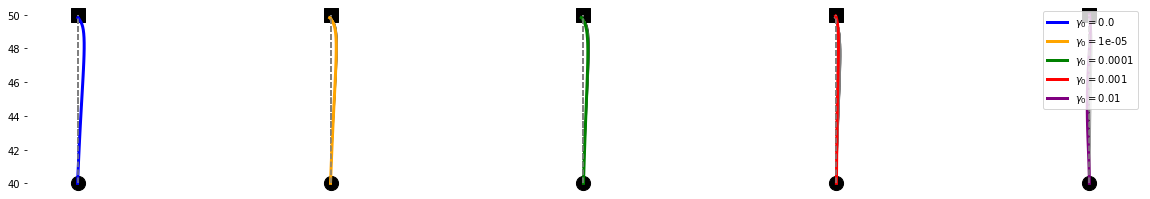

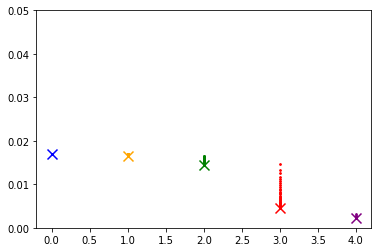

In [34]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 30
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple']
last_J = np.inf
theta_init = np.zeros((12))
GAMMA_RANGE = np.array([0,1e-5,1e-4,1e-3,1e-2])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    
    for num_iter in range(Total_Iter):
        start,end = [0,40],[0,50]
        dev = idx * 15
        X,Y,_,_,theta,J=CRAP(Duration = .4, Num_iter=40,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init)
        theta_init = theta.copy()
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        ax.plot(np.zeros(10)+dev,np.linspace(40,50,10),color = "grey",linestyle = "--")
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
            
            
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,.05)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])

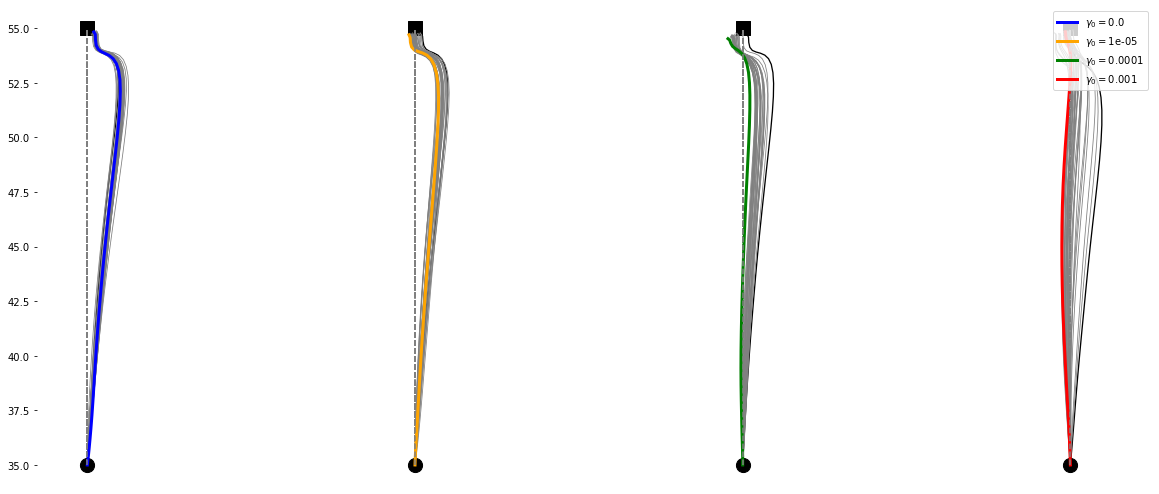

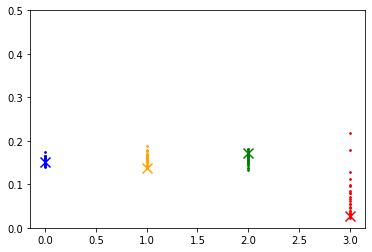

In [81]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 30
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple']
last_J = np.inf

GAMMA_RANGE = np.array([0,1e-5,1e-4,1e-3])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        start,end = [0,35],[0,55]
        dev = idx * 15
        X,Y,_,_,theta,J=CRAP(Duration = .4, Num_iter=40,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise=True)
        theta_init = theta.copy()
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        ax.plot(np.zeros(10)+dev,np.linspace(35,55,10),color = "grey",linestyle = "--")
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
            
            
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,.5)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])

# 3. Long Movements, constant gamma

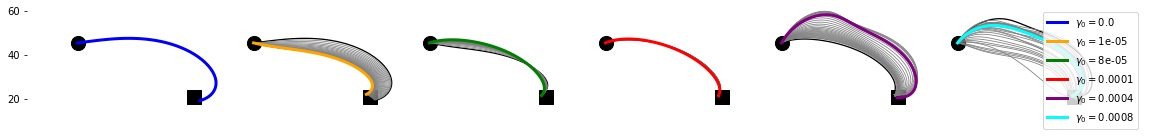

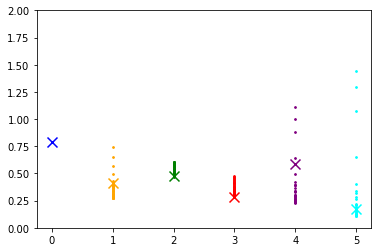

In [ ]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 30
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf
theta_init = np.zeros((12))
GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,1e-4*4,8*1e-4])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    
    for num_iter in range(Total_Iter):
        start,end = longmovement_2()
        dev = idx * 80
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init)
        theta_init = theta.copy()
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
            
            
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,2)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])
    #plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

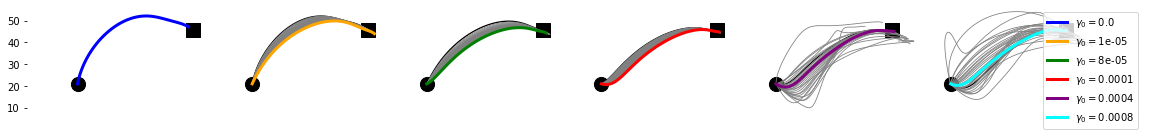

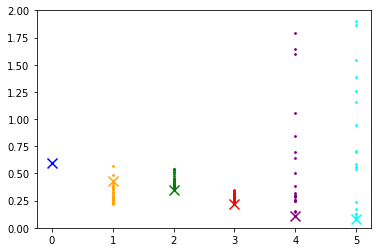

In [ ]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 30
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf
theta_init = np.zeros((12))
GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,1e-4*4,8*1e-4])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    
    for num_iter in range(Total_Iter):
        start,end = longmovement_1()
        dev = idx * 80
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init)
        theta_init = theta.copy()
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
            
            
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,2)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])
    #plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

## with noise

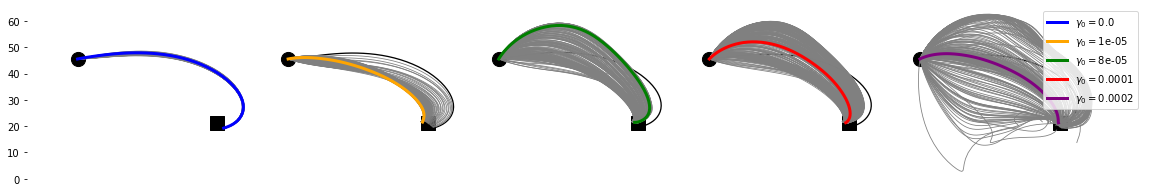

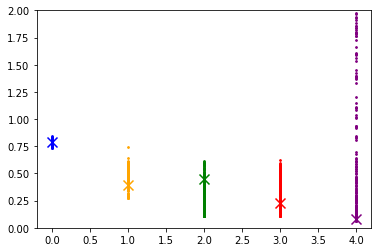

In [9]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 300
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple',"cyan"]
last_J = np.inf

GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,2e-4])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        start,end = longmovement_2()
        dev = idx * 80
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        theta_init = theta.copy()
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
            
            
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,2)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])
    #plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

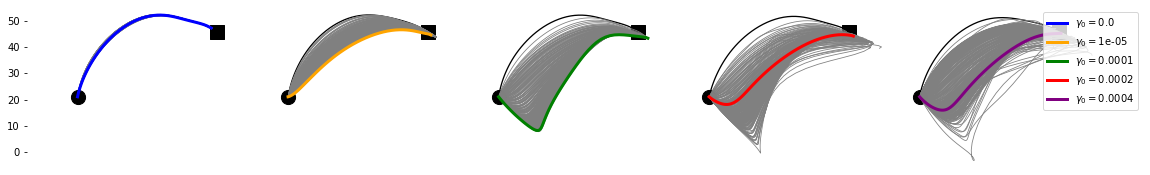

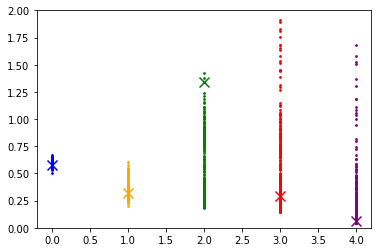

In [8]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 300
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf

GAMMA_RANGE =np.array([0,1e-5,1e-4,2e-4,1e-4*4])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        start,end = longmovement_1()
        dev = idx * 80
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        theta_init = theta.copy()
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
            
            
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,2)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])
    #plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

# Learning rate Analysis

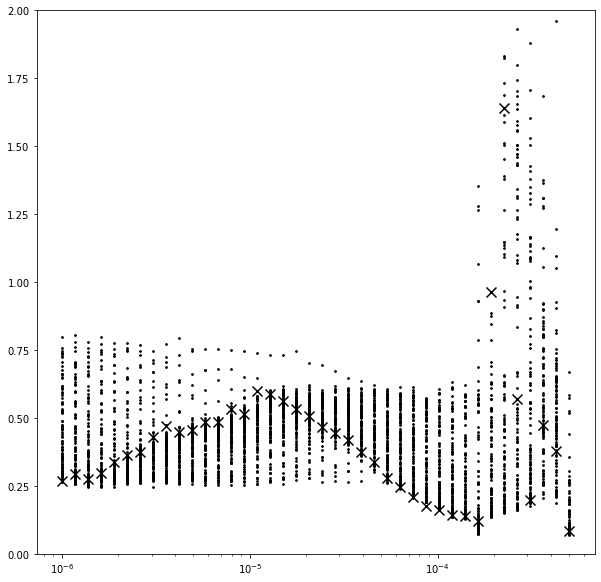

In [ ]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 100
fig,ax = plt.subplots(figsize=(10,10))

last_J = np.inf

GAMMA_RANGE = np.logspace(-6,-3.3,40)
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
start,end = longmovement_2()
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        theta_init = theta.copy()
            
        Costs[num_iter,idx] = J

plt.ylim(0,2)
plt.xticks([1e-6,1e-5,1e-4])
plt.xscale("log")
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*GAMMA_RANGE[i],Costs[:-1,i],s = 3,marker = "o",color = "black")
    plt.scatter([GAMMA_RANGE[i]],Costs[-1,i],s = 100,marker = "x",color = "black")

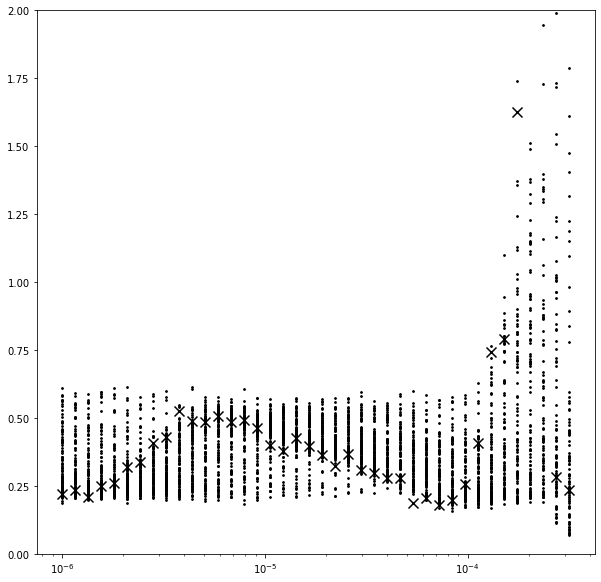

In [ ]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 100
fig,ax = plt.subplots(figsize=(10,10))

last_J = np.inf

GAMMA_RANGE = np.logspace(-6,-3.5,40)
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
start,end = longmovement_1()
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        theta_init = theta.copy()
            
        Costs[num_iter,idx] = J

plt.ylim(0,2)
plt.xticks([1e-6,1e-5,1e-4])
plt.xscale("log")
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*GAMMA_RANGE[i],Costs[:-1,i],s = 3,marker = "o",color = "black")
    plt.scatter([GAMMA_RANGE[i]],Costs[-1,i],s = 100,marker = "x",color = "black")

# 4. Long Movements, adaptive gamma

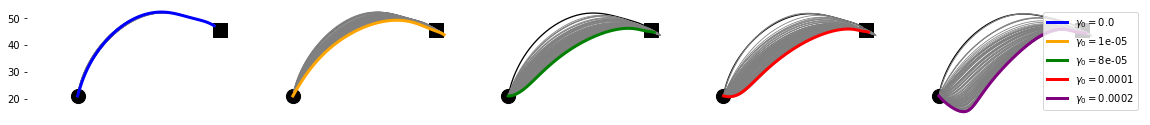

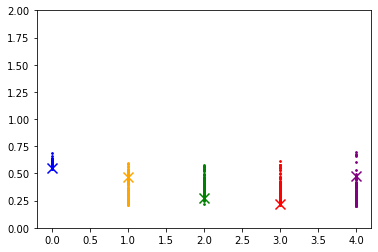

In [14]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 100
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf

GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,2e-4])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        start,end = longmovement_1()
        dev = idx * 80
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
        if J < last_J : 
            theta_init = theta.copy()
            
        #else : gamma /= 10
        last_J = J
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,2)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])
    #plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

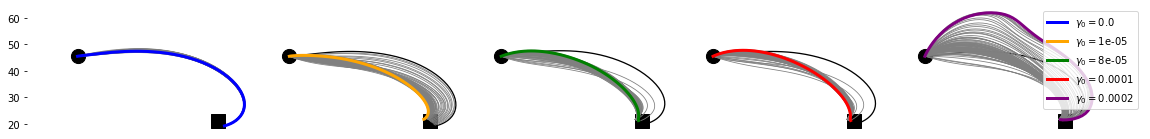

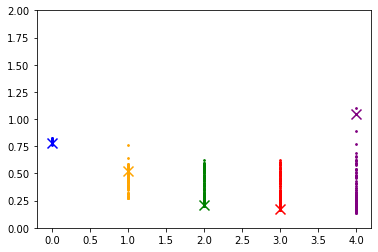

In [79]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 100
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf

GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,2e-4])
GAMMA_SIZE = len(GAMMA_RANGE)
Costs = np.zeros((Total_Iter,GAMMA_SIZE))
for idx, gamma in enumerate(GAMMA_RANGE): 
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        start,end = longmovement_2()
        dev = idx * 80
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        if num_iter == 0 : 
            color = "black"
            mylabel = ""
            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = colors[idx]
            mylabel = r"$\gamma_0 =$"+str(GAMMA_RANGE[idx])
            lw = 3
        else : 
            color = "grey"
            mylabel = ""
            lw = .8
        ax.plot(X+dev, Y, color=color, label=mylabel, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev]),
                np.array([start[1]]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev]),
                np.array([end[1]]),
                color="black",
                marker = "s",
                s = 200
            )

            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
        if True : #J < last_J : 
            theta_init = theta.copy()
            
        #else : gamma /= 10
        last_J = J
        Costs[num_iter,idx] = J

plt.show()
plt.ylim(0,2)
for i in range(GAMMA_SIZE):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = colors[i])
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = colors[i])
    #plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

# 5. Long Movements, adaptive gamma

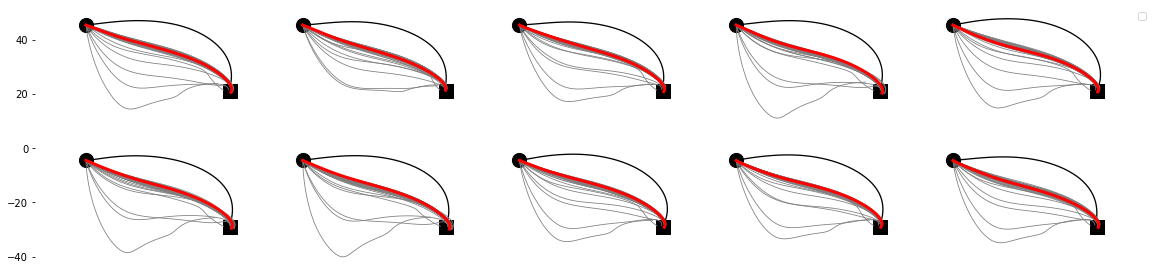

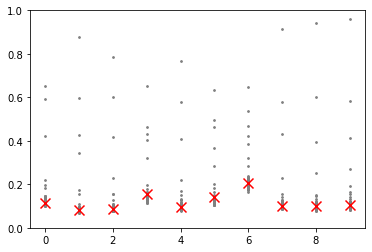

In [136]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 100
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf

Num_evol = 10
start,end = longmovement_2()
Costs = np.zeros((Total_Iter,Num_evol))


def gamma_exp(i):
    return 1e-3*np.exp(-0.4*i)
for i in range(Num_evol):
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        gamma = gamma_exp(num_iter)

        dev_x = (i%5) * 80
        dev_y = -(i//5) * 50
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        if num_iter == 0 : 
            color = "black"

            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = "red"

            lw = 3
        else : 
            color = "grey"

            lw = .8
        ax.plot(X+dev_x, Y+dev_y, color=color, linewidth=lw)
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev_x]),
                np.array([start[1]+dev_y]),
                color="black",
                marker = "o",
                s = 200
            )
            ax.scatter(
                np.array([end[0]+dev_x]),
                np.array([end[1]+dev_y]),
                color="black",
                marker = "s",
                s = 200
            )
            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
        theta_init = theta.copy()

        last_J = J
        Costs[num_iter,i] = J

plt.show()
plt.ylim(0,1)

for i in range(Num_evol):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = "grey")
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = "red")
#plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

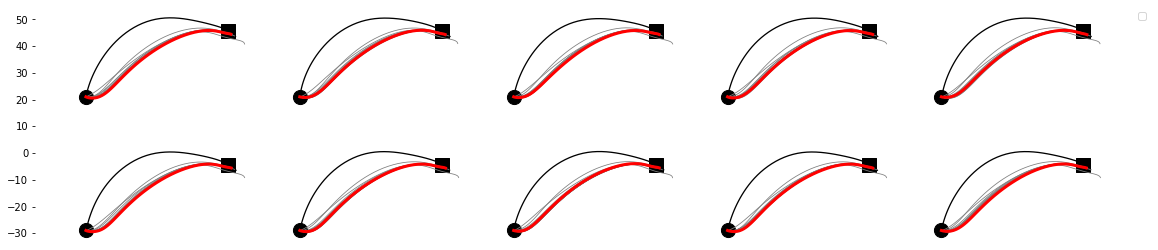

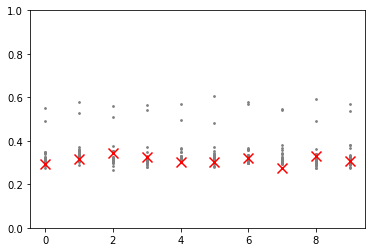

In [ ]:
import os
os.chdir('..')
from Helpers.Helpers import *
Total_Iter = 30
fig,ax = plt.subplots(figsize=(20,15))
colors = ['blue','orange','green','red','purple','cyan']
last_J = np.inf

Num_evol = 10
start,end = longmovement_1()
Costs = np.zeros((Total_Iter,Num_evol))


def gamma_exp(i):
    return 1e-3*np.exp(-0.4*i)
for i in range(Num_evol):
    theta_init = np.zeros((12))
    for num_iter in range(Total_Iter):
        gamma = gamma_exp(num_iter)

        dev_x = (i%5) * 80
        dev_y = -(i//5) * 50
        X,Y,_,_,theta,J=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta_init,Activate_Noise = True)
        if num_iter == 0 : 
            color = "black"

            lw = 1.3
        elif num_iter == Total_Iter-1 : 
            color = "red"

            lw = 3
        else : 
            color = "grey"

            lw = .8
        ax.plot(X+dev_x, Y+dev_y, color=color, linewidth=lw)
        
        
        if num_iter == Total_Iter-1:
            ax.set_aspect("equal")
            ax.scatter(
                np.array([start[0]+dev_x]),
                np.array([start[1]+dev_y]),
                color="black",
                marker = "o",
                s = 200
            ) 
            ax.scatter(
                np.array([end[0]+dev_x]),
                np.array([end[1]+dev_y]),
                color="black",
                marker = "s",
                s = 200
            )
            delete_axis(ax)
            ax.set_xticks([])
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(),by_label.keys(),fontsize = 10,loc='upper right',)
        theta_init = theta.copy()

        last_J = J
        Costs[num_iter,i] = J

plt.show()
plt.ylim(0,1)

for i in range(Num_evol):
    plt.scatter(np.ones(Total_Iter-1)*i,Costs[:-1,i],s = 3,marker = "o",color = "grey")
    plt.scatter([i],Costs[-1,i],s = 100,marker = "x",color = "red")
#plt.plot(np.arange(GAMMA_SIZE),np.ones(GAMMA_SIZE)*Best_Cost[i],color = "grey")

# 6. Comparison adaptive vs non adaptive

## Train and then evaluate

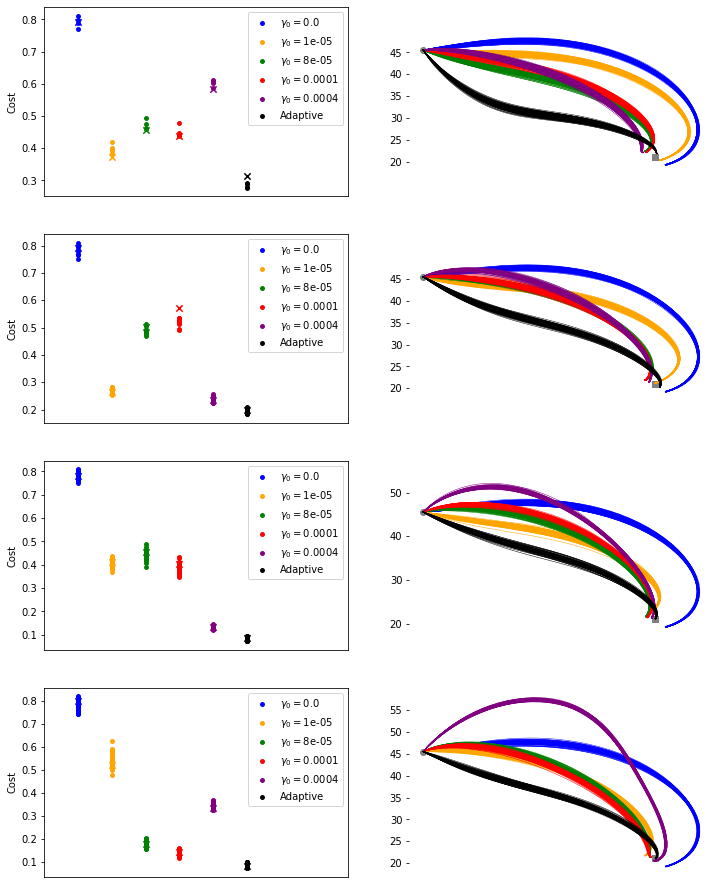

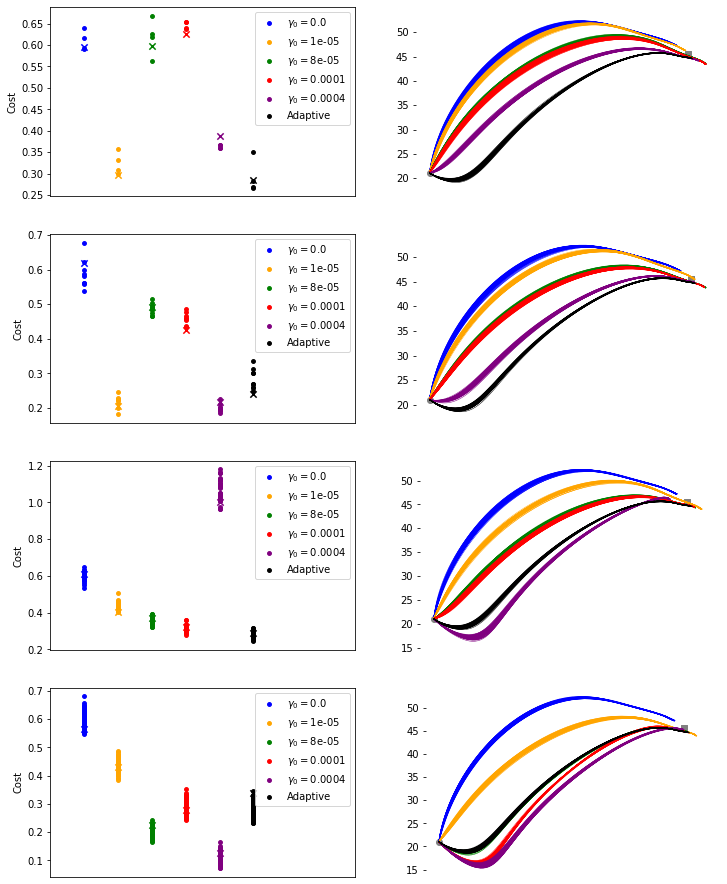

In [2]:
def get_theta_nonadaptive(GAMMA_RANGE,start,end,number_of_trials = 100):

    GAMMA_SIZE = len(GAMMA_RANGE)
    all_theta_val = np.zeros((GAMMA_SIZE,12))
    for idx,gamma in enumerate(GAMMA_RANGE): 
        theta = np.zeros((12))
        for _ in range(number_of_trials):
            
            theta=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta,Activate_Noise = True)[4]
        all_theta_val[idx] = theta

    return all_theta_val


def gamma_exp(i):
    return 1e-3*np.exp(-0.4*i)

def get_theta_adaptive(start,end,number_of_trials = 100):

    theta = np.zeros((12))
    for i in range(number_of_trials):
        theta=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma_exp(i),theta_prev = theta,Activate_Noise = True)[4]
    
    return theta

def evaluate_nonadaptive(ax,start,end,theta,number_of_trials = 100):
 
    GAMMA_SIZE = theta.shape[0]
    Costs = np.zeros((GAMMA_SIZE,number_of_trials))
    colors = ['blue','orange','green','red','purple','cyan']
    for i in range(GAMMA_SIZE):
        for j in range(number_of_trials):
            X,Y,Costs[i,j] = LQG(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,theta_prev = theta[i],Activate_Noise = True)
            ax.plot(X,Y,color = colors[i],linewidth = .5)
    return Costs

def evaluate_adaptive(ax,start,end,theta,number_of_trials = 100):
    
    Costs = np.zeros((number_of_trials))
    for i in range(number_of_trials):
        X,Y,Costs[i] = LQG(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,theta_prev = theta,Activate_Noise = True)
        ax.plot(X,Y,color = "black",linewidth = .5)

    ax.scatter([start[0]],[start[1]],marker = "o",color = "grey")    
    ax.scatter([end[0]],[end[1]],marker = "s",color = "grey") 
    return Costs

def test_best_method(movement):

    threshold_size = 4
    
    thresholds = [5,10,30,100]
    
    num_eval_trials = 100 #[10,30,60,100]
    start,end = movement()
    GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,4e-4])

    fig,ax = plt.subplots(threshold_size,2,figsize = (12,16))
    for idx,t in enumerate(thresholds):

        TRIAL_SIZE = t

        theta_nonadaptive = get_theta_nonadaptive(GAMMA_RANGE,start,end,TRIAL_SIZE)
        costs_nonadaptive = evaluate_nonadaptive(ax[idx,1],start,end,theta_nonadaptive,num_eval_trials)

        theta_adaptive = get_theta_adaptive(start,end,TRIAL_SIZE)
        costs_adaptive = evaluate_adaptive(ax[idx,1],start,end,theta_adaptive,num_eval_trials)

        GAMMA_SIZE,TRIAL_SIZE = costs_nonadaptive.shape
        colors = ['blue','orange','green','red','purple','cyan']

        ax[idx,1].set_aspect("equal")
        delete_axis(ax[idx,1])
        ax[idx,1].set_xticks([])


        for i in range(GAMMA_SIZE):
            ax[idx,0].scatter(np.ones(t-1)*i,costs_nonadaptive[i,:t-1], color = colors[i],marker = "o",label = r"$\gamma_0 =$"+str(GAMMA_RANGE[i]),s= 15)
            ax[idx,0].scatter(np.ones(1)*i,[costs_nonadaptive[i,t-1]], color = colors[i],marker = "x",s= 40)

        ax[idx,0].scatter(np.ones(t-1)*GAMMA_SIZE,costs_adaptive[:t-1], color = "black",marker = "o",label = "Adaptive",s= 15)
        ax[idx,0].scatter([GAMMA_SIZE],[costs_adaptive[t-1]], color = "black",marker = "x", s= 40)
        ax[idx,0].legend()
        ax[idx,0].set_xticks([])
        ax[idx,0].set_ylabel("Cost")
        ax[idx,0].set_xlim(-1,GAMMA_SIZE+3)
    plt.show()

test_best_method(longmovement_2)
test_best_method(longmovement_1)



## Evolution of cost while training

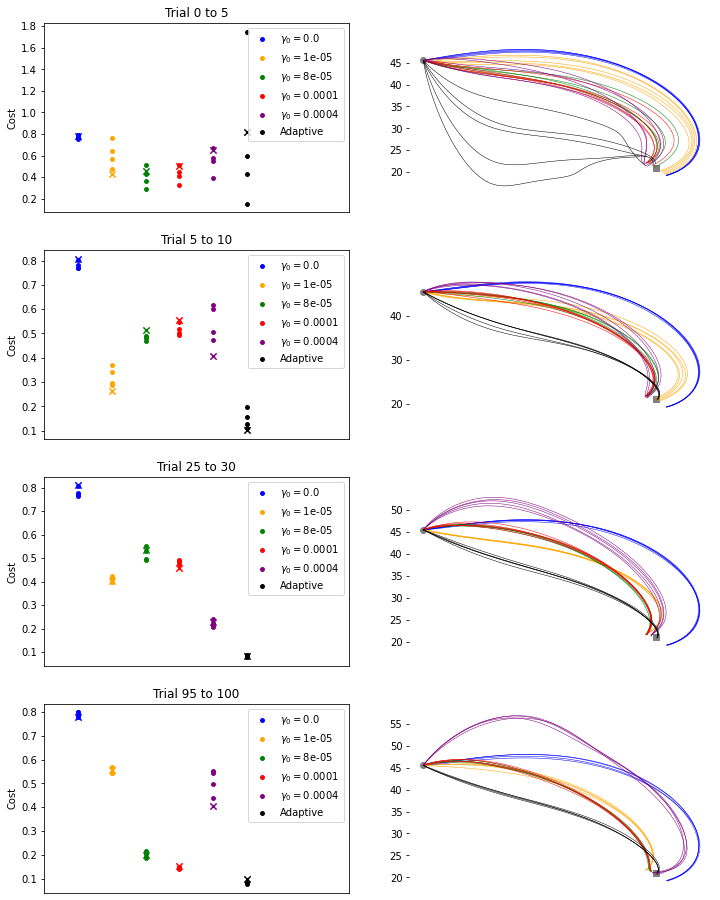

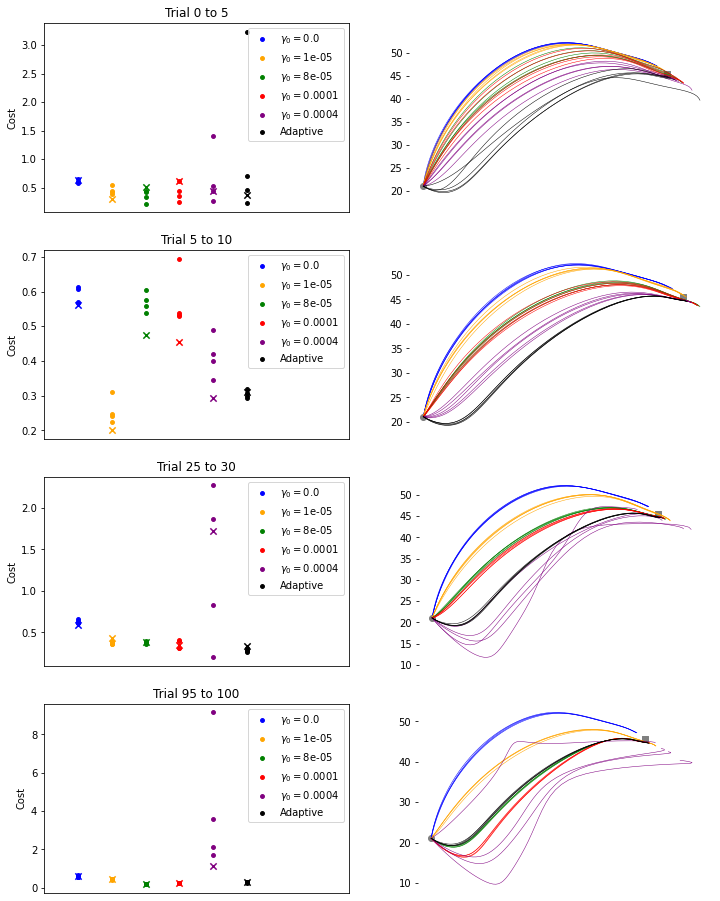

In [19]:
def direct_nonadaptive(ax,GAMMA_RANGE,start,end,number_of_trials = 100,thresholds = [],num_plotted_traj = 5):

    GAMMA_SIZE = len(GAMMA_RANGE)
    Costs = np.zeros((GAMMA_SIZE,number_of_trials))
    colors = ['blue','orange','green','red','purple','cyan']
    
    for i,gamma in enumerate(GAMMA_RANGE): 
        theta = np.zeros((12))
        idx = 0
        for j in range(number_of_trials):
            
            X,Y,_,_,theta,Costs[i,j]=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma,theta_prev = theta,Activate_Noise = True)
            if j > thresholds[idx] - num_plotted_traj:
                ax[idx].plot(X,Y,color = colors[i],linewidth = .5)
            if j == thresholds[idx]:
                idx += 1

    return Costs


def gamma_exp(i):
    return 1e-3*np.exp(-0.4*i)

def direct_adaptive(ax,start,end,number_of_trials = 100,thresholds = [],num_plotted_traj = 5):

    theta = np.zeros((12))
    Costs = np.zeros((number_of_trials))
    idx = 0
    for i in range(number_of_trials):
        X,Y,_,_,theta,Costs[i]=CRAP(Duration = .6, Num_iter=60,r1 = 1e-4,starting_point=start,targets=end,gamma = gamma_exp(i),theta_prev = theta,Activate_Noise = True)
        if i > thresholds[idx] -num_plotted_traj:
            ax[idx].plot(X,Y,color = "black",linewidth = .5)
        if i == thresholds[idx]:
            idx += 1
    for i in range(len(thresholds)):
        ax[i].scatter([start[0]],[start[1]],marker = "o",color = "grey")    
        ax[i].scatter([end[0]],[end[1]],marker = "s",color = "grey") 
    return Costs


def direct_best_method(movement):

   
    
    thresholds = [5,10,30,100]
    threshold_size = len(thresholds)
    
    num_eval_trials = max(thresholds) #[10,30,60,100]
    num_plotted_cost = 5
    start,end = movement()
    GAMMA_RANGE = np.array([0,1e-5,8*1e-5,1e-4,4e-4])
    GAMMA_SIZE = len(GAMMA_RANGE)
    colors = ['blue','orange','green','red','purple','cyan']

    fig,ax = plt.subplots(threshold_size,2,figsize = (12,16))

    costs_nonadaptive = direct_nonadaptive(ax[:,1],GAMMA_RANGE,start,end,num_eval_trials,thresholds)
    costs_adaptive = direct_adaptive(ax[:,1],start,end,num_eval_trials,thresholds)

    for idx,t in enumerate(thresholds):
        

        ax[idx,1].set_aspect("equal")
        delete_axis(ax[idx,1])
        ax[idx,1].set_xticks([])


        for i in range(GAMMA_SIZE):
            ax[idx,0].scatter(np.ones(num_plotted_cost-1)*i,costs_nonadaptive[i,t-num_plotted_cost:t-1], color = colors[i],marker = "o",label = r"$\gamma_0 =$"+str(GAMMA_RANGE[i]),s= 15)
            ax[idx,0].scatter(np.ones(1)*i,[costs_nonadaptive[i,t-1]], color = colors[i],marker = "x",s= 40)

        ax[idx,0].scatter(np.ones(num_plotted_cost-1)*GAMMA_SIZE,costs_adaptive[t-num_plotted_cost:t-1], color = "black",marker = "o",label = "Adaptive",s= 15)
        ax[idx,0].scatter([GAMMA_SIZE],[costs_adaptive[t-1]], color = "black",marker = "x", s= 40)
        ax[idx,0].legend()
        ax[idx,0].set_xticks([])
        ax[idx,0].set_ylabel("Cost")
        ax[idx,0].set_title("Trial "+str(t-num_plotted_cost)+str(" to ")+str(t))
        ax[idx,0].set_xlim(-1,GAMMA_SIZE+3)
    plt.show()

direct_best_method(longmovement_2)
direct_best_method(longmovement_1)

Tester 

- Evaluer en enlevant les états
- Tester le délai
- Tester le papier de Fred
- Tester la fonction de coût kinetic energy

# Paper Fred

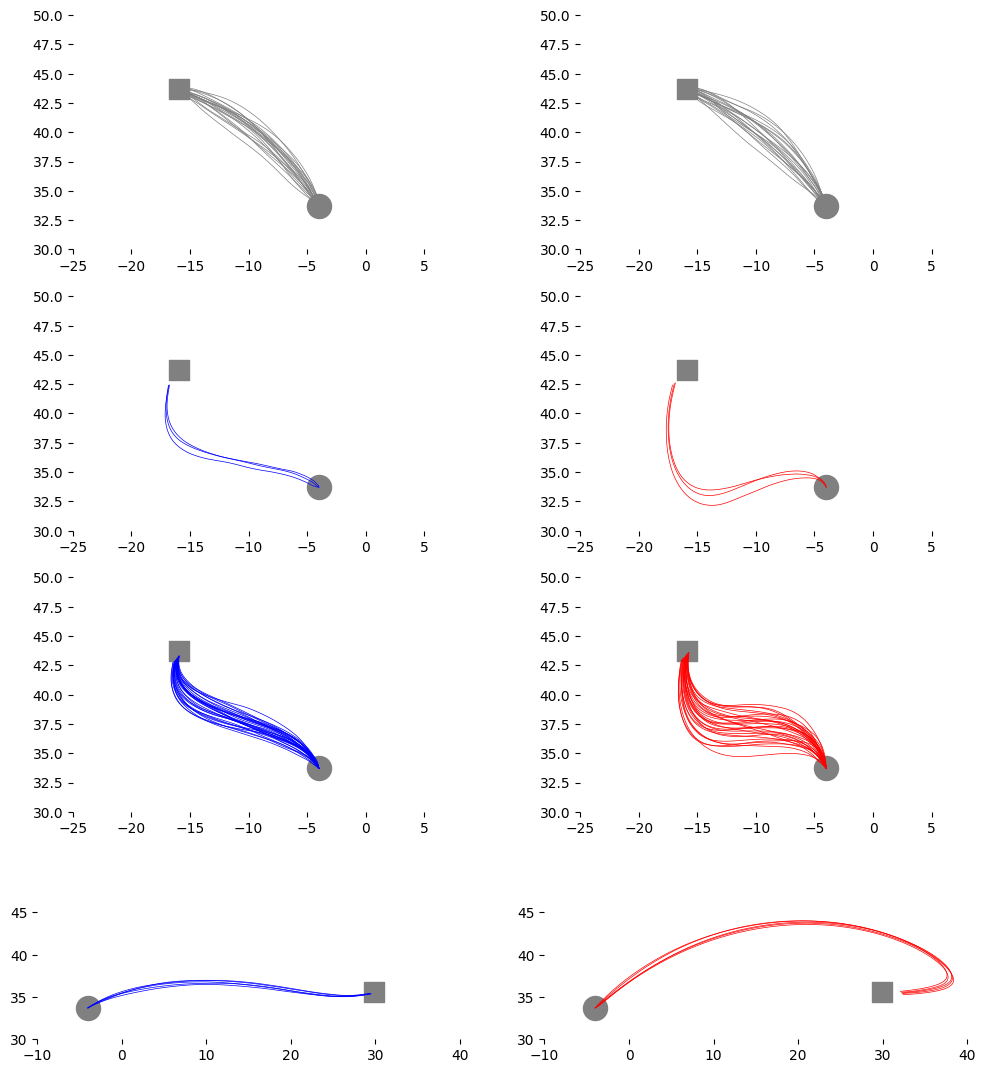

In [491]:
fig,ax = plt.subplots(4,2,figsize = (12,14))

start = ToCartesian(np.array([35,115])*np.pi/180)

end_tg1 = ToCartesian(np.array([65,85])*np.pi/180)
end_tg2 = ToCartesian(np.array([5,85])*np.pi/180)


num_training = 40
num_blocks = 5

GAMMA = 1e-6*4
add_noise = True

duration = .6
num_steps = 120

load_array = ["Viscous","Interaction"]
colors = ["blue","red"]
for i in range(2):
    theta = np.zeros(12)
    for _ in range(20):
        X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = 1e-6,starting_point=start,targets=end,gamma = 0,theta_prev = theta,Activate_Noise = add_noise, load_type = "None")
        #ax[i].plot(X,Y,color = "grey",linewidth = .5)
        ax[0,i].plot(X,Y,color = "grey",linewidth = .5)

    for j in range(num_training):
        X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = 1e-6,starting_point=start,targets=end,gamma = GAMMA,theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])
        if j <= 2 : ax[1,i].plot(X,Y,color = colors[i],linewidth = .5)
        if j >= 10 : ax[2,i].plot(X,Y,color = colors[i],linewidth = .5)
    
    for _ in range(num_blocks):
        for _ in range(1):
            X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = 1e-6,starting_point=start,targets=end_tg2,gamma = GAMMA,theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])
            ax[3,i].plot(X,Y,color = colors[i],linewidth = .5)
        for _ in range(5):
            X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = 1e-6,starting_point=start,targets=end_tg1,gamma = GAMMA,theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])

    for j in range(3):
        ax[j,i].scatter([start[0]],[start[1]],marker = "o",color = "grey", s= 300)    
        ax[j,i].scatter([end_tg1[0]],[end_tg1[1]],marker = "s",color = "grey",s = 200) 
        ax[j,i].set_ylim(30,50)
        delete_axis(ax[j,i])
        ax[j,i].set_aspect("equal")
        ax[j,i].set_xlim(-25,5)

    ax[3,i].scatter([start[0]],[start[1]],marker = "o",color = "grey", s= 300)
    ax[3,i].scatter([end_tg2[0]],[end_tg2[1]],marker = "s",color = "grey",s = 200) 
    ax[3,i].set_xlim(-10,40)
    delete_axis(ax[3,i])
    ax[3,i].set_ylim(30,45)
    ax[3,i].set_aspect("equal")

In [7]:
def gamma_exp_fred(i):
    return 1e-5*4*np.exp(-i)

def Singh_scott_expe(num_run,duration = .6, num_steps = 120, gamma_func = gamma_exp_fred):

    for _ in range(num_run):    

        _,ax = plt.subplots(6,2,figsize = (12,18))

        start = ToCartesian(np.array([35,115])*np.pi/180)

        end_tg1 = ToCartesian(np.array([65,85])*np.pi/180)
        end_tg2 = ToCartesian(np.array([5,85])*np.pi/180)


        num_training = 40
        num_blocks = 5

        r = 1e-8

        add_noise = True


        load_array = ["Viscous","Interaction"]
        colors = ["blue","red"]
        for i in range(2):
            theta = np.zeros(12)
            for _ in range(20):
                X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg1,gamma = 0,theta_prev = theta,Activate_Noise = add_noise, load_type = "None")
                #ax[i].plot(X,Y,color = "grey",linewidth = .5)
                ax[0,i].plot(X,Y,color = "grey",linewidth = .5)
                X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg2,gamma = 0,theta_prev = theta,Activate_Noise = add_noise, load_type = "None")
                #ax[i].plot(X,Y,color = "grey",linewidth = .5)
                ax[3,i].plot(X,Y,color = "grey",linewidth = .5)

            for j in range(num_training):
                X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg1,gamma = gamma_func(j),theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])
                if j <= 2 : ax[1,i].plot(X,Y,color = colors[i],linewidth = .5)
                if j >= 10 : ax[2,i].plot(X,Y,color = colors[i],linewidth = .5)
            
            for _ in range(num_blocks):
                for _ in range(1):
                    X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg2,gamma = gamma_func(0),theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])
                    ax[4,i].plot(X,Y,color = colors[i],linewidth = .5)
                for j in range(5):
                    X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg1,gamma = gamma_func(j),theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])

            for j in range(3):
                ax[j,i].scatter([start[0]],[start[1]],marker = "o",color = "grey", s= 300)    
                ax[j,i].scatter([end_tg1[0]],[end_tg1[1]],marker = "s",color = "grey",s = 200) 
                ax[j,i].set_ylim(30,50)
                delete_axis(ax[j,i])
                ax[j,i].set_aspect("equal")
                ax[j,i].set_xlim(-25,5)

            for j in [3,4,5]:

                ax[j,i].scatter([start[0]],[start[1]],marker = "o",color = "grey", s= 300)
                ax[j,i].scatter([end_tg2[0]],[end_tg2[1]],marker = "s",color = "grey",s = 200) 
                ax[j,i].set_xlim(-10,40)
                delete_axis(ax[j,i])
                ax[j,i].set_ylim(30,45)
                ax[j,i].set_aspect("equal")

        for i in range(2):
            theta = np.zeros(12)

            for j in range(num_training):
                X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg1,gamma = gamma_func(j),theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])
            
            for _ in range(num_blocks):
                for _ in range(1):
                    X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg2,gamma = gamma_func(0),theta_prev = theta,Activate_Noise = add_noise, load_type = "None")
                    ax[5,i].plot(X,Y,color = colors[i],linewidth = .5)
                for j in range(5):
                    X,Y,_,_,theta,J=Linear_CRAP(Duration = duration, Num_iter=num_steps,r1 = r,starting_point=start,targets=end_tg1,gamma = gamma_func(j),theta_prev = theta,Activate_Noise = add_noise, load_type = load_array[i])

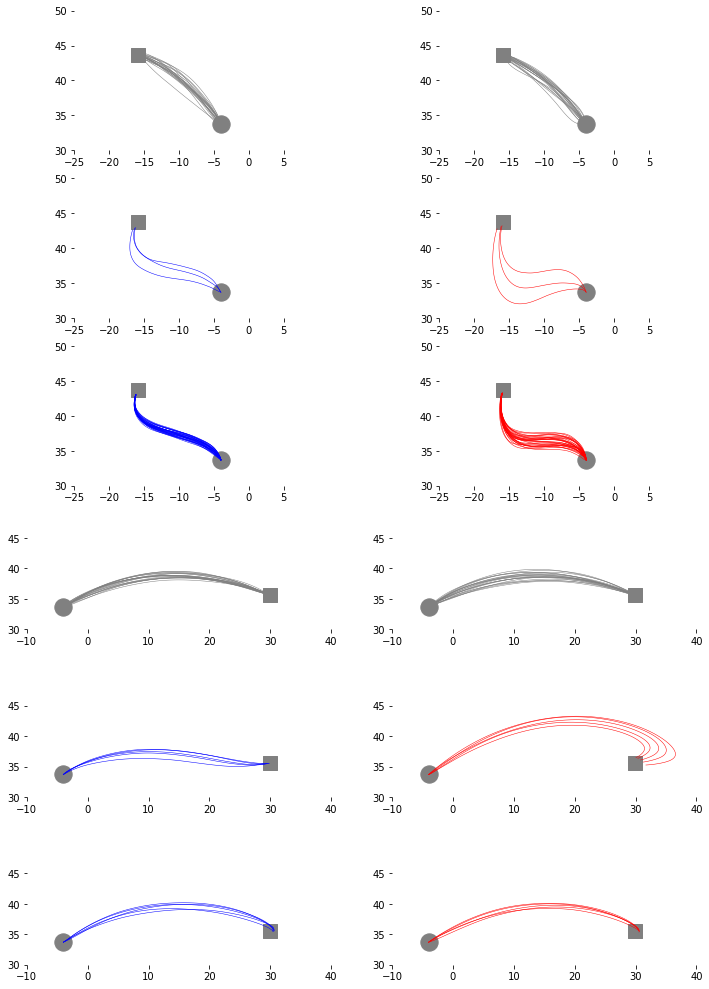

In [8]:
Singh_scott_expe(1)

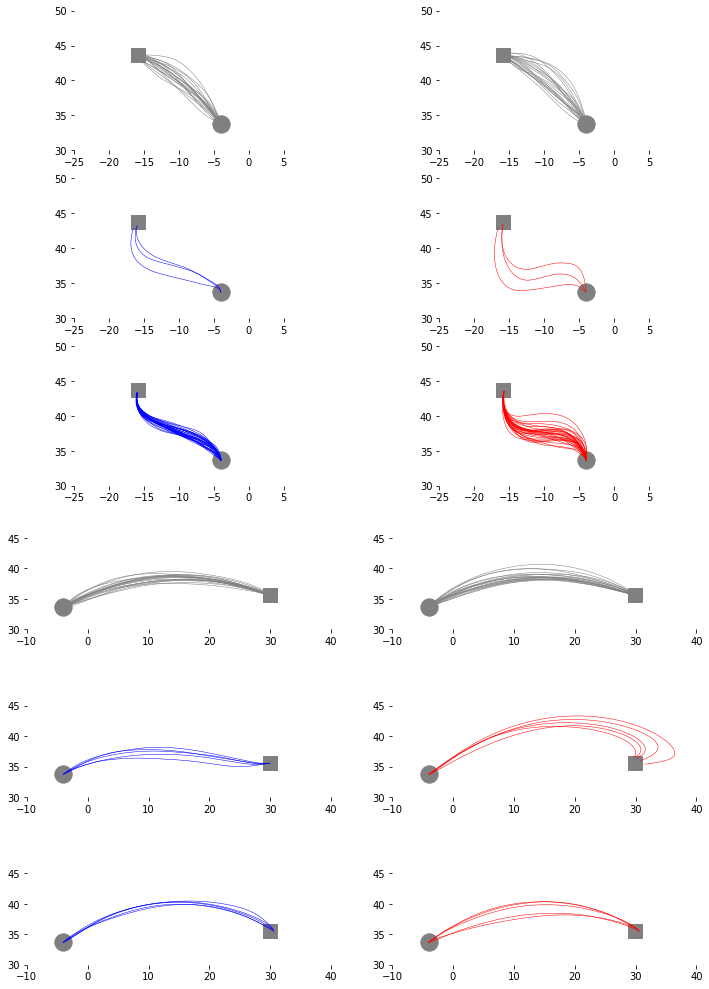

In [9]:
def gamma_test(i):
    return 1e-5*np.exp(-i)

Singh_scott_expe(1,num_steps=300,gamma_func=gamma_test)

plt.savefig("SinghExp.svg",dpi = 300)